In [2]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import particle
from particle import Particle
import seaborn as sns

DET_I = 5 #SBND Index
DET_A = 4*np.pi*1e4 # Detector area


In [3]:
with uproot.open("./DATA/NuBeam_production_BooNE_50m_I174000A_0.dk2nu.root") as f:
    
    tree = f[f.keys()[0]]
    meta = f[f.keys()[2]]

    nuray_E   = tree["nuray"]["nuray.E"].array()
    nuray_wgt = tree["nuray"]["nuray.wgt"].array()
    nimpwt    = tree["decay"]["decay.nimpwt"].array()
    ntype     = tree["decay"]["decay.ntype"].array()
    ptype     = tree["decay"]["decay.ptype"].array() 
    pots = meta["pots"].array()

    # Selection Variables
    px = tree["nuray"]["nuray.px"].array()
    py = tree["nuray"]["nuray.py"].array()
    pz = tree["nuray"]["nuray.pz"].array()

    decay_x = tree["decay"]["decay.vx"].array()
    decay_y = tree["decay"]["decay.vy"].array()
    decay_z = tree["decay"]["decay.vz"].array()


# Select SBND
energies = nuray_E[:,DET_I]
wgts     = nuray_wgt[:,DET_I]
tot_wgts = nimpwt * wgts / (DET_A * pots[0])

energy_range = (energies <= 1) & (energies >= 0)
is_numu      = (ntype == 14)

flavours = {
     14: (r"$\nu_\mu$",     "blue"),
    -14: (r"$\bar\nu_\mu$", "orange"),
     12: (r"$\nu_e$",       "green"),
    -12: (r"$\bar\nu_e$",   "red"),
}

parent_groups = {
    "mu" : (np.isin(ptype, [13,-13]), "blue"),
    "pi" : (np.isin(ptype, [211,-211]), "orange"),
    "K0L" : (np.isin(ptype, [130]), "red"),
    "Kpm" : (np.isin(ptype, [321, -321]), "green")
}

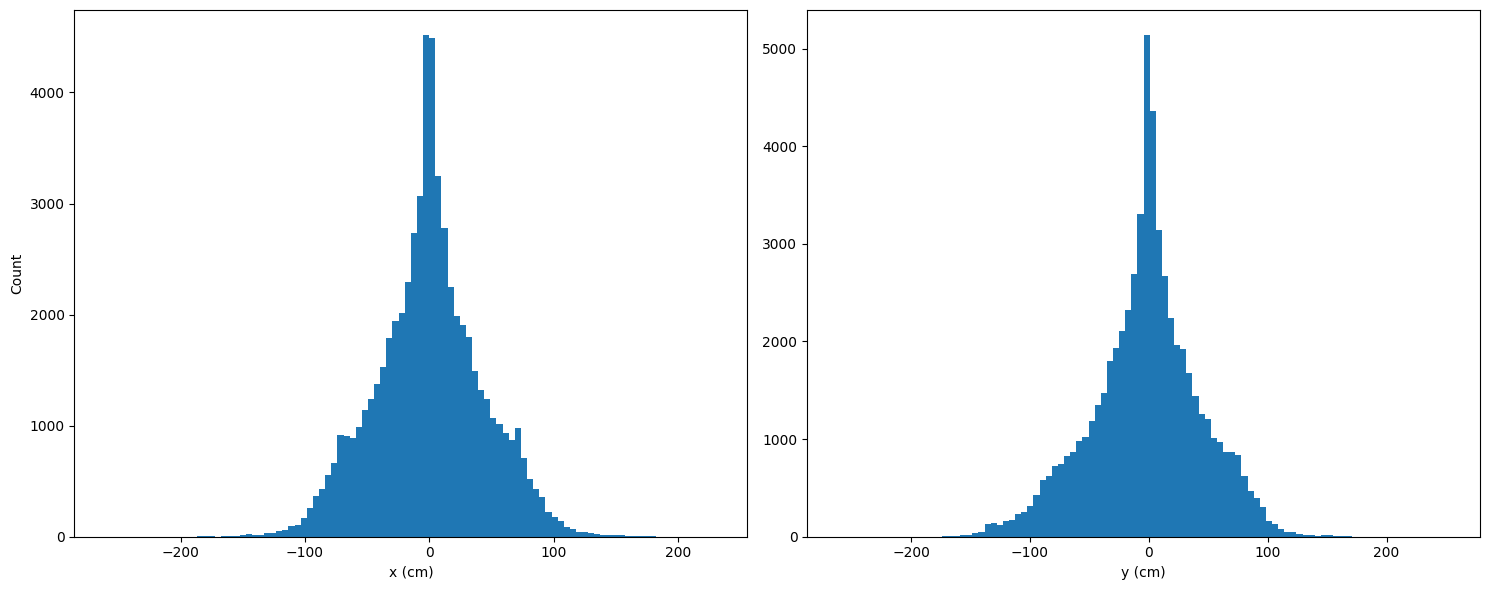

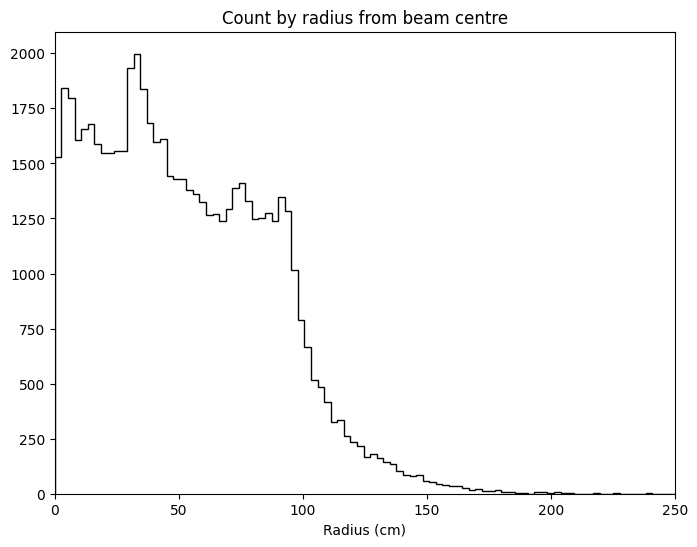

In [4]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
ax1.hist(decay_x, bins=100) # Does this need to be weighted like the flux?
ax2.hist(decay_y, bins=100)

ax1.set_xlabel("x (cm)")
ax1.set_ylabel("Count")
ax2.set_xlabel("y (cm)")

fig.tight_layout()

radii = np.sqrt(decay_x**2 + decay_y**2)
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(radii, bins=100,histtype="step", color="black")

ax.set_xlim(0,250)
ax.set_xlabel("Radius (cm)")
ax.set_title("Count by radius from beam centre")
plt.show()

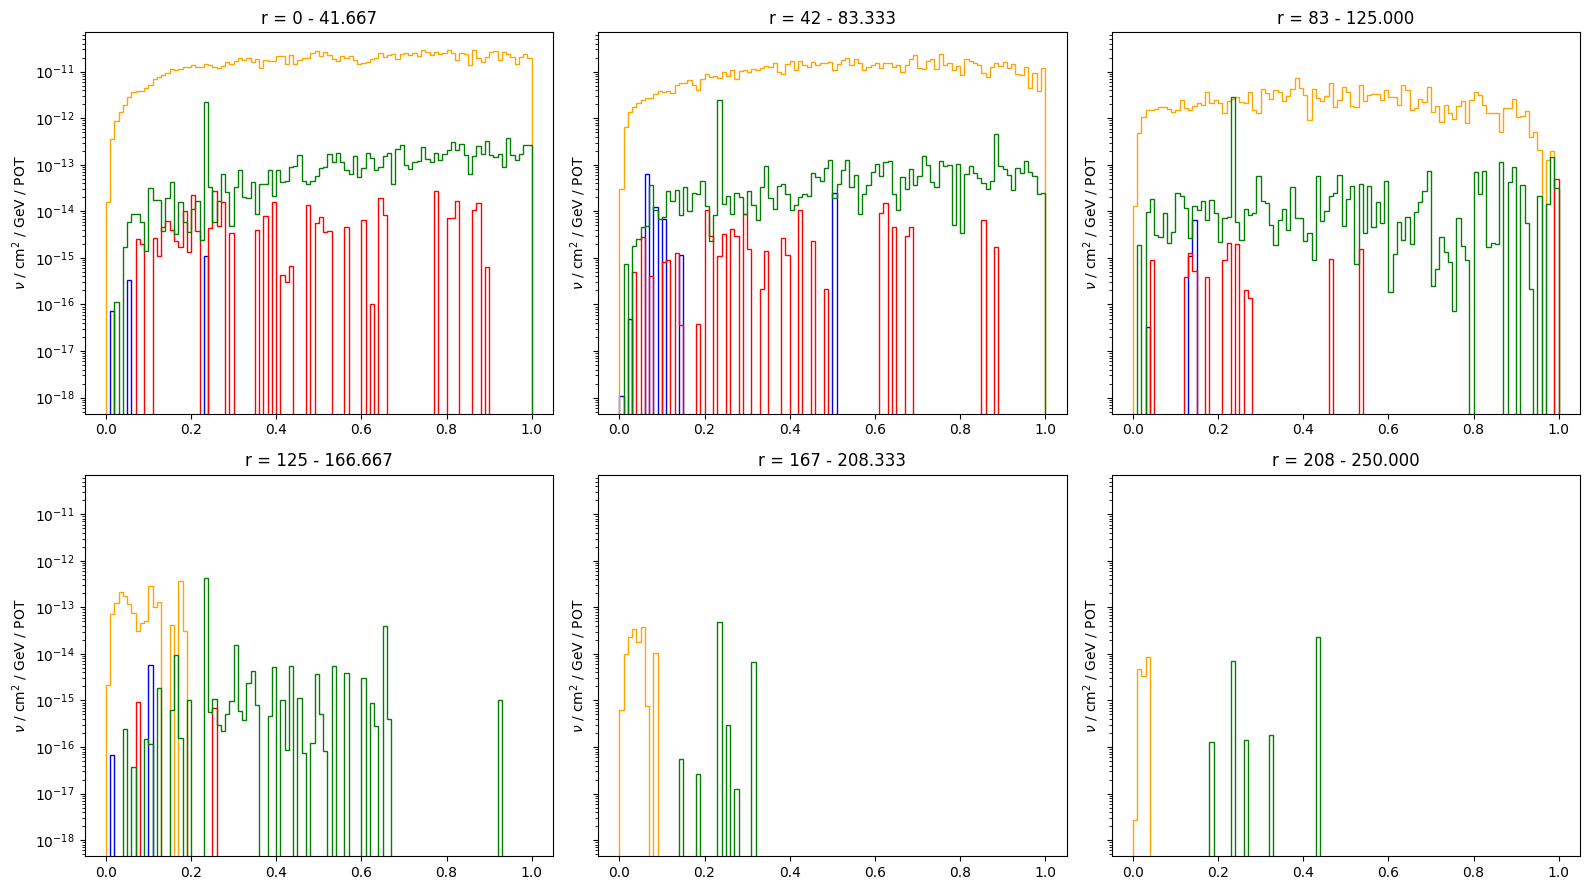

In [ ]:

rows, columns = 2, 3
fig, axs = plt.subplots(rows,columns, figsize=(16, 9), sharey=True)
bins = np.linspace(0, 1, 101)  # GeV

nbins = rows * columns
edges = np.linspace(0,250,nbins+1)

radial_masks = []
for i in range(len(edges)-1):
    radial_masks.append((radii >= edges[i]) & (radii < edges[i+1]))



for r in range(rows):
    for c in range(columns):
        
        mask = is_numu & radial_masks[r*columns + c] & energy_range

        for label, (parent_mask, colour) in parent_groups.items():
                axs[r][c].hist(energies[mask & parent_mask], bins=bins, weights=tot_wgts[mask & parent_mask],
                        label=label, color=colour, histtype="step", linewidth=1)

        axs[r][c].set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
        axs[r][c].set_yscale("log")
        axs[r][c].set_title(f"r = {(r*columns + c)*(250/nbins):.1f} - {(r*columns + c+1)*(250/nbins):.1f}")

fig.tight_layout()
plt.show()




